In [55]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..") / "00-foundation"))

import numpy as np
import cv2
import matplotlib.pyplot as plt
from Autograd import WhyyTorch as wt, mse_loss, cross_entropy_loss

In [73]:
np.random.seed(42)

In [74]:
import json
from pathlib import Path
DATA_DIR = Path("data/images")
LABELS_PATH = Path("data/labels.json")
IMG_SIZE = 128
labels = json.loads(LABELS_PATH.read_text())

In [75]:
X_list = []
Y_list = []
group_list = []  # original source id — keeps augs with their parent

for item in labels:
    img = cv2.imread(str(DATA_DIR / item["image"]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0

    if item["has_ball"]:
        y = [item["cx"], item["cy"], item["w"], item["h"], 1.0]
    else:
        y = [0.0, 0.0, 0.0, 0.0, 0.0]

    # Augmented rows have "source"; originals are their own group
    group = item.get("source", item["image"])
    X_list.append(img)
    Y_list.append(y)
    group_list.append(group)

X = np.array(X_list)
Y = np.array(Y_list)
groups = np.array(group_list)  

In [76]:
# Split by SOURCE groups, not individual images — prevents aug leakage
np.random.seed(42)
unique_groups = np.unique(groups)
perm = np.random.permutation(unique_groups)
n_train_groups = int(0.8 * len(perm))
train_groups = set(perm[:n_train_groups])
test_groups = set(perm[n_train_groups:])

train_mask = np.array([g in train_groups for g in groups])
test_mask = np.array([g in test_groups for g in groups])

x_train, y_train = X[train_mask], Y[train_mask]
x_test, y_test = X[test_mask], Y[test_mask]

# Shuffle within each split only
tr = np.random.permutation(len(x_train))
te = np.random.permutation(len(x_test))
x_train, y_train = x_train[tr], y_train[tr]
x_test, y_test = x_test[te], y_test[te]

print(
    f"sources: {len(unique_groups)} total | "
    f"{len(train_groups)} train | {len(test_groups)} val"
)
print(
    f"images:  {len(X)} total | "
    f"{len(x_train)} train | {len(x_test)} val"
)
# Sanity: no source appears in both splits
assert train_groups.isdisjoint(test_groups)

sources: 60 total | 48 train | 12 val
images:  540 total | 432 train | 108 val


In [77]:
X.shape,Y.shape

((540, 128, 128, 3), (540, 5))

In [78]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((432, 128, 128, 3), (432, 5), (108, 128, 128, 3), (108, 5))

### Verification

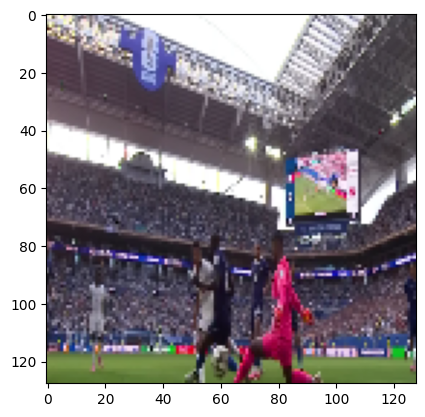

In [93]:
plt.imshow(X[7])

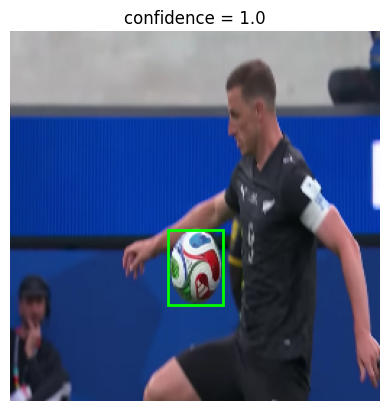

In [46]:
img = x_train[7]
cx, cy, w, h, conf = y_train[7]
h_img, w_img = img.shape[:2]
x1 = (cx - w/2) * w_img
y1 = (cy - h/2) * h_img
x2 = (cx + w/2) * w_img
y2 = (cy + h/2) * h_img
plt.imshow(img)
plt.gca().add_patch(plt.Rectangle((x1, y1), w*w_img, h*h_img, fill=False, color="lime", linewidth=2))
plt.title(f"confidence = {conf}")
plt.axis("off")
plt.show()

### Model

In [8]:
def _as_wt(x, requires_grad=False):
    """Accept numpy or WhyyTorch; return WhyyTorch."""
    if isinstance(x, wt):
        return x
    return wt(x, requires_grad=requires_grad)


class Conv2d:
    """Conv with WhyyTorch params. Forward is numpy; backward hooks into wt graph."""

    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        # NOTE: stride/padding stored but not applied in forward yet
        scale = np.sqrt(2.0 / (kernel_size * kernel_size * in_channels))
        self.kernels = wt(
            np.random.randn(out_channels, kernel_size, kernel_size, in_channels).astype(np.float32) * scale
        )
        self.biases = wt(np.zeros(out_channels, dtype=np.float32))

    def forward(self, x):
        x = _as_wt(x)
        xd = x.data
        kd = self.kernels.data
        bd = self.biases.data
        ks = self.kernel_size

        h_out = xd.shape[0] - ks + 1
        w_out = xd.shape[1] - ks + 1
        out_data = np.zeros((h_out, w_out, self.out_channels), dtype=np.float32)

        for i in range(self.out_channels):
            kernel = kd[i]
            bias = bd[i]
            for j in range(h_out):
                for k in range(w_out):
                    patch = xd[j:j + ks, k:k + ks]
                    out_data[j, k, i] = np.sum(patch * kernel) + bias

        out = wt(
            out_data,
            requires_grad=x.requires_grad or self.kernels.requires_grad or self.biases.requires_grad,
            _op="conv2d",
            children=(x, self.kernels, self.biases),
        )

        def backward():
            g = out.grad  # (H_out, W_out, out_channels)
            grad_input = np.zeros_like(xd)
            grad_kernels = np.zeros_like(kd)
            grad_biases = np.zeros_like(bd)

            for i in range(self.out_channels):
                for j in range(h_out):
                    for k in range(w_out):
                        patch = xd[j:j + ks, k:k + ks]
                        gi = g[j, k, i]
                        grad_input[j:j + ks, k:k + ks] += gi * kd[i]
                        grad_kernels[i] += gi * patch
                        grad_biases[i] += gi

            x._accumulate_grad(grad_input)
            self.kernels._accumulate_grad(grad_kernels)
            self.biases._accumulate_grad(grad_biases)

        out._backward = backward
        return out

    def parameters(self):
        return [self.kernels, self.biases]


class MaxPool2d:
    """MaxPool with mask routing hooked into WhyyTorch graph."""

    def __init__(self, kernel_size):
        self.kernel_size = kernel_size

    def forward(self, x):
        x = _as_wt(x)
        xd = x.data
        ks = self.kernel_size
        out_h = xd.shape[0] // ks
        out_w = xd.shape[1] // ks
        out_data = np.zeros((out_h, out_w, xd.shape[2]), dtype=np.float32)
        max_mask = np.zeros_like(xd, dtype=bool)

        for i in range(out_h):
            for j in range(out_w):
                for c in range(xd.shape[2]):
                    window = xd[i * ks:(i + 1) * ks, j * ks:(j + 1) * ks, c]
                    flat_idx = int(np.argmax(window))
                    out_data[i, j, c] = window.flat[flat_idx]
                    wi, wj = np.unravel_index(flat_idx, window.shape)
                    max_mask[i * ks + wi, j * ks + wj, c] = True

        out = wt(
            out_data,
            requires_grad=x.requires_grad,
            _op="maxpool2d",
            children=(x,),
        )

        def backward():
            grad_input = np.zeros_like(xd, dtype=np.float32)
            g = out.grad
            for i in range(g.shape[0]):
                for j in range(g.shape[1]):
                    for c in range(g.shape[2]):
                        window_mask = max_mask[i * ks:(i + 1) * ks, j * ks:(j + 1) * ks, c]
                        grad_input[i * ks:(i + 1) * ks, j * ks:(j + 1) * ks, c][window_mask] += g[i, j, c]
            x._accumulate_grad(grad_input)

        out._backward = backward
        return out

    def parameters(self):
        return []



class ReLU:
    def forward(self, x):
        x = _as_wt(x)
        return x.relu()

    def parameters(self):
        return []


class Flatten:
    def forward(self, x):
        x = _as_wt(x)
        return x.reshape(-1)

    def parameters(self):
        return []


class Linear:
    """Same idea as Autograd.Linear, with .forward for Sequential."""

    def __init__(self, in_features, out_features):
        scale = np.sqrt(2.0 / in_features)
        self.weight = wt(np.random.randn(in_features, out_features).astype(np.float32) * scale)
        self.bias = wt(np.zeros(out_features, dtype=np.float32))

    def forward(self, x):
        x = _as_wt(x)
        return x @ self.weight + self.bias

    def parameters(self):
        return [self.weight, self.bias]


class Sequential:
    def __init__(self, *layers):
        self.layers = list(layers)

    def __call__(self, x):
        x = _as_wt(x, requires_grad=False)  # images are inputs, not params
        for layer in self.layers:
            x = layer.forward(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.zero_grad()

    def step(self, lr):
        for p in self.parameters():
            p.data -= lr * p.grad




In [39]:
out = Conv2d(3, 5, 3).forward(X[0])
print(out.shape)
print(out[0, 0, 0], out[0, 0, 1], out[0, 0, 2])  

(254, 254, 5)
3.8370125366168413 -1.2311103800681338 -1.8117334750779268


In [12]:
# One forward pass — create layers once, reuse them
conv1 = Conv2d(3, 8, 3) # 3 -> 8 channels, kernel size 3
pool1 = MaxPool2d(2) # 
conv2 = Conv2d(8, 16, 3)
pool2 = MaxPool2d(2)
flatten = Flatten()
for i in range(1):
    x = X[i]
    print("input:  ", x.shape)

    x = conv1.forward(x)
    print("conv1:  ", x.shape)

    x = pool1.forward(x)
    print("pool1:  ", x.shape)

    x = conv2.forward(x)
    print("conv2:  ", x.shape)

    x = pool2.forward(x)
    print("pool2:  ", x.shape)

    flat = flatten.forward(x)
    print("flatten:", flat.shape)

    head = Linear(flat.shape[0], 5)
    out = head.forward(flat)
    print("output: ", out.shape)
    print(out)




input:   (256, 256, 3)
conv1:   (254, 254, 8)
pool1:   (127, 127, 8)
conv2:   (125, 125, 16)
pool2:   (62, 62, 16)
flatten: (61504,)
output:  (5,)
[ 33.60511345  18.47913647 -19.88049727 -16.18043994 -49.31100046]


In [9]:
model = Sequential(
    Conv2d(3, 8, 3),   # 3 channels -> 8 feature maps
    ReLU(),
    MaxPool2d(2),      # 2 kernel size
    Conv2d(8, 16, 3),  # 8 feature maps -> 16 feature maps
    ReLU(),
    MaxPool2d(2),      # 2 kernel size
    Flatten(),         # (62, 62, 16) -> 61504
    Linear(61504, 5),  # 61504 -> [cx, cy, w, h, conf]
)



In [14]:
out = model(X[0])
print(out.shape)
print(out)

(5,)
[ 33.60511345  18.47913647 -19.88049727 -16.18043994 -49.31100046]


In [ ]:
def detection_loss(pred, target, w_cxcy=5.0, w_wh=2.0, w_conf=1.0):
    """Split detection loss on WhyyTorch graph.

    pred: wt shape (5,) = [cx, cy, w, h, conf] (decoded)
    target: array-like (5,) = [cx, cy, w, h, conf]

    Returns:
        total: scalar wt to call .backward() on once
        parts: dict of individual loss tensors (for logging)
    """
    target = _as_wt(target, requires_grad=False)
    has_ball = float(target.data[4])  # mask bbox terms when no ball

    # position loss (only when ball exists)
    cxcy_err = pred[0:2] - target[0:2]
    loss_cxcy = (cxcy_err ** 2).mean() * has_ball

    # size loss (only when ball exists)
    wh_err = pred[2:4] - target[2:4]
    loss_wh = (wh_err ** 2).mean() * has_ball

    # confidence loss (always) — BCE, not MSE
    # use python float t so only p stays in autograd graph
    # (mixing two no-grad wt tensors like `one - t` breaks backward in WhyyTorch)
    p = pred[4]
    t_conf = float(target.data[4])
    if t_conf >= 0.5:
        loss_conf = -p.log()
    else:
        loss_conf = -(wt(1.0, requires_grad=False) - p).log()

    total = w_cxcy * loss_cxcy + w_wh * loss_wh + w_conf * loss_conf
    parts = {
        "cxcy": loss_cxcy,
        "wh": loss_wh,
        "conf": loss_conf,
        "total": total,
    }
    return total, parts


def detection_mse_loss(pred, target):
    """Backward-compatible wrapper — returns only total loss."""
    total, _ = detection_loss(pred, target)
    return total
def sigmoid(x):
    """Elementwise sigmoid for WhyyTorch tensors."""
    return 1.0 / (1.0 + (-x).exp())


def softplus(x):
    """Smooth positive map: log(1 + exp(x))."""
    return (1.0 + x.exp()).log()


def _stack5(cx, cy, w, h, conf):
    """Stack 5 scalar wt values into shape (5,) with autograd."""
    parts = (cx, cy, w, h, conf)
    data = np.array([float(np.asarray(p.data).reshape(())) for p in parts], dtype=np.float32)
    out = wt(
        data,
        requires_grad=any(p.requires_grad for p in parts),
        _op="stack5",
        children=parts,
    )

    def backward():
        for i, p in enumerate(parts):
            p._accumulate_grad(np.array(out.grad[i], dtype=np.float32))

    out._backward = backward
    return out


def decode_detection(raw):
    """Decode Linear logits -> valid detection outputs.
    cx, cy, conf: sigmoid -> (0, 1)
    w, h: softplus -> > 0
    """
    raw = _as_wt(raw)
    cx = sigmoid(raw[0])
    cy = sigmoid(raw[1])
    w = softplus(raw[2])
    h = softplus(raw[3])
    conf = sigmoid(raw[4])
    return _stack5(cx, cy, w, h, conf)



In [42]:
# Training Loop
train_len = 25
epochs = 10
lr = 1e-3

for epoch in range(epochs):
    total_loss = 0.0
    for i in range(train_len):
        model.zero_grad()

        raw = model(x_train[i])           # Linear logits 
        pred = decode_detection(raw)      # constrained [cx,cy,w,h,conf]
        loss = detection_mse_loss(pred, y_train[i])

        loss.backward()
        model.step(lr)
        total_loss += float(loss.data)
    if epoch % 1 == 0:
        print(f"epoch {epoch}: loss={total_loss / train_len:.6f}")



KeyboardInterrupt: 

In [ ]:
# Save / load WhyyTorch model weights (train in short sessions)
from pathlib import Path

CKPT_PATH = Path("ball_cnn_checkpoint.npz")

def save_weights(model, path=CKPT_PATH):
    blobs = {}
    for i, layer in enumerate(model.layers):
        for j, p in enumerate(layer.parameters()):
            blobs[f"layer{i}_param{j}"] = p.data
    np.savez(path, **blobs)
    print(f"Saved {len(blobs)} tensors -> {path.resolve()}")

def load_weights(model, path=CKPT_PATH):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"No checkpoint at {path}")
    data = np.load(path)
    expected = sum(len(layer.parameters()) for layer in model.layers)
    if len(data.files) != expected:
        raise ValueError(
            f"Checkpoint has {len(data.files)} arrays, model expects {expected}. "
            "Re-create the same Sequential architecture before loading."
        )
    n = 0
    for i, layer in enumerate(model.layers):
        for j, p in enumerate(layer.parameters()):
            arr = data[f"layer{i}_param{j}"]
            if arr.shape != p.data.shape:
                raise ValueError(
                    f"Shape mismatch at layer {i} param {j}: ckpt {arr.shape} vs model {p.data.shape}"
                )
            p.data = arr.astype(np.float32)
            if p.requires_grad:
                p.zero_grad()
            n += 1
    print(f"Loaded {n} tensors <- {path.resolve()}")

# After a training session:
save_weights(model)

# Next session: run model = Sequential(...) with the SAME architecture, then:
# load_weights(model)
# ... continue training loop



ground truth: [0. 0. 0. 0. 0.]
prediction:   [0.41007608 0.55188906 0.15210967 0.16412616 0.81573725]


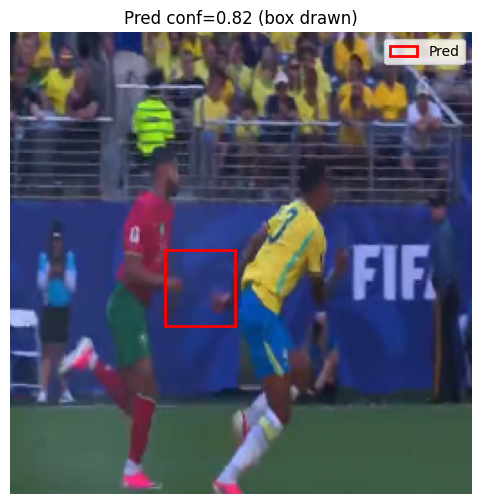

In [41]:
# Visual test on 1 test image
idx = 11  # change this to try other test images
img = x_train[idx]
gt = y_train[idx]

raw = model(img)
pred = decode_detection(raw).data  # [cx, cy, w, h, conf]
print("ground truth:", gt)
print("prediction:  ", pred)

h_img, w_img = img.shape[:2]

def box_from_label(label):
    cx, cy, w, h, conf = label
    x1 = (cx - w / 2) * w_img
    y1 = (cy - h / 2) * h_img
    return x1, y1, w * w_img, h * h_img, conf

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(img)

# Ground truth (lime) — only if ball exists
if gt[4] > 0.5:
    x1, y1, bw, bh, _ = box_from_label(gt)
    ax.add_patch(plt.Rectangle((x1, y1), bw, bh, fill=False, color="lime", linewidth=2, label="GT"))

# Prediction (red) — only draw box if model is confident
CONF_THRESH = 0.5
px1, py1, pbw, pbh, pconf = box_from_label(pred)
if pconf > CONF_THRESH:
    ax.add_patch(plt.Rectangle((px1, py1), pbw, pbh, fill=False, color="red", linewidth=2, label="Pred"))
    title = f"Pred conf={pconf:.2f} (box drawn)"
else:
    title = f"Pred conf={pconf:.2f} < {CONF_THRESH} -> no ball"

ax.set_title(title)
ax.axis("off")
ax.legend(loc="upper right")
plt.show()



In [43]:
import time
t0 = time.perf_counter()
model.zero_grad()
raw = model(x_train[0])
pred = decode_detection(raw)
loss = detection_mse_loss(pred, y_train[0])
loss.backward()
model.step(lr)
print(time.perf_counter() - t0)

8.0152914999926


### Optmized 

In [79]:
def _as_wt(x, requires_grad=False):
    """Accept numpy or WhyyTorch; return WhyyTorch."""
    if isinstance(x, wt):
        return x
    return wt(x, requires_grad=requires_grad)


class Conv2d:
    """Conv with WhyyTorch params. Forward is numpy; backward hooks into wt graph."""

    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        # NOTE: stride/padding stored but not applied in forward yet
        scale = np.sqrt(2.0 / (kernel_size * kernel_size * in_channels))
        self.kernels = wt(
            np.random.randn(out_channels, kernel_size, kernel_size, in_channels).astype(np.float32) * scale
        )
        self.biases = wt(np.zeros(out_channels, dtype=np.float32))

    def forward(self, x):
        x = _as_wt(x)
        xd = x.data
        kd = self.kernels.data
        bd = self.biases.data
        ks = self.kernel_size

        h_out = xd.shape[0] - ks + 1
        w_out = xd.shape[1] - ks + 1
        N = h_out * w_out
        
        patches = np.zeros((N, ks * ks * xd.shape[2]), dtype=np.float32)
        for i in range(h_out):
            for j in range(w_out):
                patches[i * w_out + j] = xd[i:i+ks, j:j+ks].reshape(-1)
        kernels_flat = kd.reshape(self.out_channels, -1)
        out_2d = patches @ kernels_flat.T + bd
        out_data = out_2d.reshape(h_out, w_out, self.out_channels)
        
        # for i in range(self.out_channels):
        #     kernel = kd[i]
        #     bias = bd[i]
        #     for j in range(h_out):
        #         for k in range(w_out):
        #             patch = xd[j:j + ks, k:k + ks]
        #             out_data[j, k, i] = np.sum(patch * kernel) + bias
        self._patches = patches
        self._kernels_flat = kernels_flat
        self._h_out = h_out
        self._w_out = w_out
        out = wt(
            out_data,
            requires_grad=x.requires_grad or self.kernels.requires_grad or self.biases.requires_grad,
            _op="conv2d",
            children=(x, self.kernels, self.biases),
        )

        def backward():
            g = out.grad  # (H_out, W_out, out_channels)
            g2d = g.reshape(h_out * w_out, self.out_channels)   # (N, C_out)

            # --- vectorized backward (im2col) ---
            grad_kernels_flat = g2d.T @ self._patches          # (C_out, ks*ks*C_in)
            grad_kernels = grad_kernels_flat.reshape(kd.shape)
            grad_biases = g2d.sum(axis=0)                      # (C_out,)

            grad_patches = g2d @ self._kernels_flat            # (N, ks*ks*C_in)
            grad_input = np.zeros_like(xd)
            for i in range(h_out):
                for j in range(w_out):
                    grad_input[i:i + ks, j:j + ks] += grad_patches[i * w_out + j].reshape(ks, ks, xd.shape[2])

            # --- old loop backward (slow) ---
            # grad_input = np.zeros_like(xd)
            # grad_kernels = np.zeros_like(kd)
            # grad_biases = np.zeros_like(bd)
            # for i in range(self.out_channels):
            #     for j in range(h_out):
            #         for k in range(w_out):
            #             patch = xd[j:j + ks, k:k + ks]
            #             gi = g[j, k, i]
            #             grad_input[j:j + ks, k:k + ks] += gi * kd[i]
            #             grad_kernels[i] += gi * patch
            #             grad_biases[i] += gi

            x._accumulate_grad(grad_input)
            self.kernels._accumulate_grad(grad_kernels)
            self.biases._accumulate_grad(grad_biases)

        out._backward = backward
        return out

    def parameters(self):
        return [self.kernels, self.biases]


class MaxPool2d:
    """MaxPool with mask routing hooked into WhyyTorch graph."""

    def __init__(self, kernel_size):
        self.kernel_size = kernel_size

    def forward(self, x):
        x = _as_wt(x)
        xd = x.data
        ks = self.kernel_size
        out_h = xd.shape[0] // ks
        out_w = xd.shape[1] // ks
        out_data = np.zeros((out_h, out_w, xd.shape[2]), dtype=np.float32)
        max_mask = np.zeros_like(xd, dtype=bool)

        for i in range(out_h):
            for j in range(out_w):
                for c in range(xd.shape[2]):
                    window = xd[i * ks:(i + 1) * ks, j * ks:(j + 1) * ks, c]
                    flat_idx = int(np.argmax(window))
                    out_data[i, j, c] = window.flat[flat_idx]
                    wi, wj = np.unravel_index(flat_idx, window.shape)
                    max_mask[i * ks + wi, j * ks + wj, c] = True

        out = wt(
            out_data,
            requires_grad=x.requires_grad,
            _op="maxpool2d",
            children=(x,),
        )

        def backward():
            grad_input = np.zeros_like(xd, dtype=np.float32)
            g = out.grad
            for i in range(g.shape[0]):
                for j in range(g.shape[1]):
                    for c in range(g.shape[2]):
                        window_mask = max_mask[i * ks:(i + 1) * ks, j * ks:(j + 1) * ks, c]
                        grad_input[i * ks:(i + 1) * ks, j * ks:(j + 1) * ks, c][window_mask] += g[i, j, c]
            x._accumulate_grad(grad_input)

        out._backward = backward
        return out

    def parameters(self):
        return []



class ReLU:
    def forward(self, x):
        x = _as_wt(x)
        return x.relu()

    def parameters(self):
        return []


class Flatten:
    def forward(self, x):
        x = _as_wt(x)
        return x.reshape(-1)

    def parameters(self):
        return []


class Linear:
    """Same idea as Autograd.Linear, with .forward for Sequential."""

    def __init__(self, in_features, out_features):
        scale = np.sqrt(2.0 / in_features)
        self.weight = wt(np.random.randn(in_features, out_features).astype(np.float32) * scale)
        self.bias = wt(np.zeros(out_features, dtype=np.float32))

    def forward(self, x):
        x = _as_wt(x)
        return x @ self.weight + self.bias

    def parameters(self):
        return [self.weight, self.bias]


class Sequential:
    def __init__(self, *layers):
        self.layers = list(layers)

    def __call__(self, x):
        x = _as_wt(x, requires_grad=False)  # images are inputs, not params
        for layer in self.layers:
            x = layer.forward(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.zero_grad()

    def step(self, lr):
        for p in self.parameters():
            p.data -= lr * p.grad


In [80]:
def detection_loss(pred, target, w_cxcy=5.0, w_wh=2.0, w_conf=1.0):
    """Split detection loss on WhyyTorch graph.

    pred: wt shape (5,) = [cx, cy, w, h, conf] (decoded)
    target: array-like (5,) = [cx, cy, w, h, conf]

    Returns:
        total: scalar wt to call .backward() on once
        parts: dict of individual loss tensors (for logging)
    """
    target = _as_wt(target, requires_grad=False)
    has_ball = float(target.data[4])  # mask bbox terms when no ball

    # position loss (only when ball exists)
    cxcy_err = pred[0:2] - target[0:2]
    loss_cxcy = (cxcy_err ** 2).mean() * has_ball

    # size loss (only when ball exists)
    wh_err = pred[2:4] - target[2:4]
    loss_wh = (wh_err ** 2).mean() * has_ball

    # confidence loss (always) — BCE, not MSE
    # use python float t so only p stays in autograd graph
    # (mixing two no-grad wt tensors like `one - t` breaks backward in WhyyTorch)
    p = pred[4]
    t_conf = float(target.data[4])
    if t_conf >= 0.5:
        loss_conf = -p.log()
    else:
        loss_conf = -(wt(1.0, requires_grad=False) - p).log()

    total = w_cxcy * loss_cxcy + w_wh * loss_wh + w_conf * loss_conf
    parts = {
        "cxcy": loss_cxcy,
        "wh": loss_wh,
        "conf": loss_conf,
        "total": total,
    }
    return total, parts


def detection_mse_loss(pred, target):
    """Backward-compatible wrapper — returns only total loss."""
    total, _ = detection_loss(pred, target)
    return total
def sigmoid(x):
    """Elementwise sigmoid for WhyyTorch tensors."""
    return 1.0 / (1.0 + (-x).exp())


def softplus(x):
    """Smooth positive map: log(1 + exp(x))."""
    return (1.0 + x.exp()).log()


def _stack5(cx, cy, w, h, conf):
    """Stack 5 scalar wt values into shape (5,) with autograd."""
    parts = (cx, cy, w, h, conf)
    data = np.array([float(np.asarray(p.data).reshape(())) for p in parts], dtype=np.float32)
    out = wt(
        data,
        requires_grad=any(p.requires_grad for p in parts),
        _op="stack5",
        children=parts,
    )

    def backward():
        for i, p in enumerate(parts):
            p._accumulate_grad(np.array(out.grad[i], dtype=np.float32))

    out._backward = backward
    return out


def decode_detection(raw):
    """Decode Linear logits -> valid detection outputs.
    cx, cy, conf: sigmoid -> (0, 1)
    w, h: softplus -> > 0
    """
    raw = _as_wt(raw)
    cx = sigmoid(raw[0])
    cy = sigmoid(raw[1])
    w = softplus(raw[2])
    h = softplus(raw[3])
    conf = sigmoid(raw[4])
    return _stack5(cx, cy, w, h, conf)



In [50]:
conv1 = Conv2d(3, 8, 3) 
import time
t0 = time.perf_counter()
out = conv1.forward(x_train[0])
print(out.shape, out.data.mean(), time.perf_counter() - t0)

(254, 254, 8) -0.037365995 0.16448559999116696


In [66]:
model2 = Sequential(
    Conv2d(3, 4, 3), # input channels, output feature maps, kernel size
    ReLU(), # Non linear activation
    MaxPool2d(2), # kernel size 
    Conv2d(4, 8, 3), # input feature maps, output feature maps, kernel size
    ReLU(), # Non linear activation
    MaxPool2d(2), # kernel size
    Flatten(), # Flattern 224 x 224 x 16 -> 61504 
    Linear(7200, 5), # 61504 -> 5 output 
)

In [81]:
train_len = 100  # or len(x_train) for all 48
epochs = 10
lr = 1e-3


for epoch in range(epochs):
    # --- train ---
    total_loss = 0.0
    cxcy_loss = 0.0
    wh_loss = 0.0
    conf_loss = 0.0
    for i in range(train_len):
        model2.zero_grad()
        raw = model2(x_train[i])
        pred = decode_detection(raw)
        loss, parts = detection_loss(pred, y_train[i])
        loss.backward()
        model2.step(lr)
        total_loss += float(parts["total"].data)
        cxcy_loss += float(parts["cxcy"].data)
        wh_loss += float(parts["wh"].data)
        conf_loss += float(parts["conf"].data)
    n = train_len
    train_loss = total_loss / n
    train_cxcy = cxcy_loss / n
    train_wh = wh_loss / n
    train_conf = conf_loss / n

    # --- validation (no grad, no weight update) ---
    val_total = 0.0
    val_cxcy = 0.0
    val_wh = 0.0
    val_conf = 0.0
    for i in range(len(x_test)):
        raw = model2(x_test[i])
        pred = decode_detection(raw)
        _, parts = detection_loss(pred, y_test[i])
        val_total += float(parts["total"].data)
        val_cxcy += float(parts["cxcy"].data)
        val_wh += float(parts["wh"].data)
        val_conf += float(parts["conf"].data)
    m = len(x_test)
    val_loss = val_total / m
    val_cxcy /= m
    val_wh /= m
    val_conf /= m

    print(
        f"epoch {epoch}: "
        f"train={train_loss:.4f} (cxcy={train_cxcy:.4f} wh={train_wh:.4f} conf={train_conf:.4f})  "
        f"val={val_loss:.4f} (cxcy={val_cxcy:.4f} wh={val_wh:.4f} conf={val_conf:.4f})"
    )

epoch 0: train=0.2670 (cxcy=0.0217 wh=0.0040 conf=0.1504)  val=0.3444 (cxcy=0.0282 wh=0.0054 conf=0.1923)
epoch 1: train=0.1929 (cxcy=0.0128 wh=0.0040 conf=0.1210)  val=0.3382 (cxcy=0.0278 wh=0.0057 conf=0.1878)
epoch 2: train=0.1510 (cxcy=0.0086 wh=0.0038 conf=0.1001)  val=0.3346 (cxcy=0.0279 wh=0.0058 conf=0.1838)
epoch 3: train=0.1231 (cxcy=0.0062 wh=0.0037 conf=0.0846)  val=0.3321 (cxcy=0.0281 wh=0.0058 conf=0.1801)
epoch 4: train=0.1030 (cxcy=0.0046 wh=0.0036 conf=0.0727)  val=0.3307 (cxcy=0.0285 wh=0.0057 conf=0.1766)
epoch 5: train=0.0878 (cxcy=0.0035 wh=0.0034 conf=0.0633)  val=0.3306 (cxcy=0.0292 wh=0.0056 conf=0.1734)
epoch 6: train=0.0755 (cxcy=0.0027 wh=0.0033 conf=0.0557)  val=0.3315 (cxcy=0.0300 wh=0.0055 conf=0.1705)
epoch 7: train=0.0650 (cxcy=0.0019 wh=0.0032 conf=0.0493)  val=0.3321 (cxcy=0.0307 wh=0.0054 conf=0.1678)
epoch 8: train=0.0562 (cxcy=0.0012 wh=0.0030 conf=0.0439)  val=0.3317 (cxcy=0.0311 wh=0.0053 conf=0.1655)
epoch 9: train=0.0495 (cxcy=0.0009 wh=0.0029 c

#### Logs

Initial : Img 256x256 , 2 Conv, 2 Max Pool: size 2 ,
1. feature maps : conv1 8  , conv2 16 , Train Loss:0.116 Validation Loss: 0.16
2. feature maps : conv1 16 , conv2 32 , Train Loss:0.116 Validation Loss: 0.16 -> 0.62
3. Img 64x64 , feature maps : conv1 4 , conv2 8 , Train Loss:0.169 Validation Loss: 0.175
4. Img 128x128 , feature maps : conv1 4 , conv2 8 , train_len 40 , Train Loss:0.106 Validation Loss: 0.168 -> 0.183

ground truth: [0.505425 0.608614 0.117541 0.11236  1.      ]
prediction:   [0.22920156 0.7242962  0.15321793 0.09614724 0.77991897]


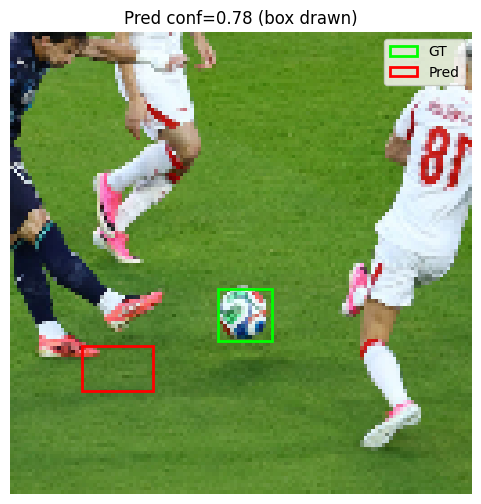

In [72]:
# Visual test on 1 test image
idx = 10  # change this to try other test images
img = x_test[idx]
gt = y_test[idx]

raw = model2(img)
pred = decode_detection(raw).data  # [cx, cy, w, h, conf]
print("ground truth:", gt)
print("prediction:  ", pred)

h_img, w_img = img.shape[:2]

def box_from_label(label):
    cx, cy, w, h, conf = label
    x1 = (cx - w / 2) * w_img
    y1 = (cy - h / 2) * h_img
    return x1, y1, w * w_img, h * h_img, conf

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(img)

# Ground truth (lime) — only if ball exists
if gt[4] > 0.5:
    x1, y1, bw, bh, _ = box_from_label(gt)
    ax.add_patch(plt.Rectangle((x1, y1), bw, bh, fill=False, color="lime", linewidth=2, label="GT"))

# Prediction (red) — only draw box if model is confident
CONF_THRESH = 0.5
px1, py1, pbw, pbh, pconf = box_from_label(pred)
if pconf > CONF_THRESH:
    ax.add_patch(plt.Rectangle((px1, py1), pbw, pbh, fill=False, color="red", linewidth=2, label="Pred"))
    title = f"Pred conf={pconf:.2f} (box drawn)"
else:
    title = f"Pred conf={pconf:.2f} < {CONF_THRESH} -> no ball"

ax.set_title(title)
ax.axis("off")
ax.legend(loc="upper right")
plt.show()

In [96]:
x = x_train[0]
for layer in model2.layers[:-1]:   # everything except Linear
    x = layer.forward(x)
print(x.shape)   # should print (1568,)

(7200,)


### One overfitting test

Train on image_1 .. image_7 originals + all their augmented copies.
Goal: loss near 0 and red box on the ball.


In [47]:
# Load image_1 .. image_7 originals + all image_N_aug_* samples
# reload labels from disk so new augmented entries are always picked up
labels = json.loads(LABELS_PATH.read_text())

IMG_IDS = range(1, 8)  # 1 to 7


def is_overfit_image(name: str) -> bool:
    for n in IMG_IDS:
        if name == f"image_{n}.png" or name.startswith(f"image_{n}_aug_"):
            return True
    return False


img7_items = [item for item in labels if is_overfit_image(item["image"])]
img7_items = sorted(img7_items, key=lambda item: item["image"])

x_img7_list = []
y_img7_list = []
img7_names = []

for item in img7_items:
    img = cv2.imread(str(DATA_DIR / item["image"]))
    if img is None:
        raise FileNotFoundError(f"Missing file: {DATA_DIR / item['image']}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0

    if item["has_ball"]:
        y = [item["cx"], item["cy"], item["w"], item["h"], 1.0]
    else:
        y = [0.0, 0.0, 0.0, 0.0, 0.0]

    x_img7_list.append(img)
    y_img7_list.append(y)
    img7_names.append(item["image"])

x_img7 = np.array(x_img7_list)
y_img7 = np.array(y_img7_list)

# train on all loaded samples; validate on originals image_1 .. image_7 only
img7_train_idx = np.arange(len(x_img7))
img7_val_idx = [img7_names.index(f"image_{n}.png") for n in IMG_IDS]

print(f"loaded {len(x_img7)} images")
for n in IMG_IDS:
    base = f"image_{n}.png"
    count = sum(1 for name in img7_names if name == base or name.startswith(f"image_{n}_aug_"))
    print(f"  image_{n}: {count} samples")
print("val images:", [img7_names[i] for i in img7_val_idx])

expected = len(IMG_IDS) * 9  # 1 original + 8 aug per image
if len(x_img7) != expected:
    print(f"WARNING: expected {expected} samples — re-run data/augment_images.py --all-ball or per image")

loaded 63 images
  image_1: 9 samples
  image_2: 9 samples
  image_3: 9 samples
  image_4: 9 samples
  image_5: 9 samples
  image_6: 9 samples
  image_7: 9 samples
val images: ['image_1.png', 'image_2.png', 'image_3.png', 'image_4.png', 'image_5.png', 'image_6.png', 'image_7.png']


In [48]:
# Fresh model for image_7 overfit test
model_img7 = Sequential(
    Conv2d(3, 4, 3),
    ReLU(),
    MaxPool2d(2),
    Conv2d(4, 8, 3),
    ReLU(),
    MaxPool2d(2),
    Flatten(),
    Linear(7200, 5),
)

(63, 128, 128, 3)

In [51]:
epochs = 25
lr = 1e-3

for epoch in range(epochs):
    order = np.random.permutation(len(x_img7))

    total_loss = 0.0
    cxcy_loss = 0.0
    wh_loss = 0.0
    conf_loss = 0.0

    for i in order:
        model_img7.zero_grad()
        raw = model_img7(x_img7[i])
        pred = decode_detection(raw)
        loss, parts = detection_loss(pred, y_img7[i])
        loss.backward()
        model_img7.step(lr)

        total_loss += float(parts["total"].data)
        cxcy_loss += float(parts["cxcy"].data)
        wh_loss += float(parts["wh"].data)
        conf_loss += float(parts["conf"].data)

    n = len(x_img7)
    train_loss = total_loss / n
    train_cxcy = cxcy_loss / n
    train_wh = wh_loss / n
    train_conf = conf_loss / n

    val_total = 0.0
    val_cxcy = 0.0
    val_wh = 0.0
    val_conf = 0.0
    for vi in img7_val_idx:
        raw = model_img7(x_img7[vi])
        pred = decode_detection(raw)
        _, val_parts = detection_loss(pred, y_img7[vi])
        val_total += float(val_parts["total"].data)
        val_cxcy += float(val_parts["cxcy"].data)
        val_wh += float(val_parts["wh"].data)
        val_conf += float(val_parts["conf"].data)

    m = len(img7_val_idx)
    val_loss = val_total / m
    val_cxcy /= m
    val_wh /= m
    val_conf /= m

    if epoch % 1 == 0 or epoch == epochs - 1:
        print(
            f"epoch {epoch}: "
            f"train={train_loss:.4f} (cxcy={train_cxcy:.4f} wh={train_wh:.4f} conf={train_conf:.4f})  "
            f"val={val_loss:.4f} (cxcy={val_cxcy:.4f} wh={val_wh:.4f} conf={val_conf:.4f})"
        )

epoch 0: train=0.3704 (cxcy=0.0530 wh=0.0208 conf=0.0638)  val=0.1498 (cxcy=0.0243 wh=0.0074 conf=0.0136)
epoch 1: train=0.1730 (cxcy=0.0295 wh=0.0081 conf=0.0094)  val=0.0689 (cxcy=0.0098 wh=0.0069 conf=0.0063)
epoch 2: train=0.1062 (cxcy=0.0171 wh=0.0078 conf=0.0051)  val=0.0365 (cxcy=0.0040 wh=0.0063 conf=0.0040)
epoch 3: train=0.0681 (cxcy=0.0100 wh=0.0073 conf=0.0034)  val=0.0396 (cxcy=0.0051 wh=0.0057 conf=0.0026)
epoch 4: train=0.0499 (cxcy=0.0068 wh=0.0068 conf=0.0024)  val=0.0183 (cxcy=0.0013 wh=0.0050 conf=0.0019)
epoch 5: train=0.0378 (cxcy=0.0047 wh=0.0062 conf=0.0018)  val=0.0151 (cxcy=0.0010 wh=0.0044 conf=0.0014)
epoch 6: train=0.0298 (cxcy=0.0034 wh=0.0057 conf=0.0014)  val=0.0201 (cxcy=0.0023 wh=0.0037 conf=0.0011)
epoch 7: train=0.0228 (cxcy=0.0023 wh=0.0051 conf=0.0011)  val=0.0082 (cxcy=0.0002 wh=0.0031 conf=0.0009)
epoch 8: train=0.0196 (cxcy=0.0019 wh=0.0046 conf=0.0009)  val=0.0066 (cxcy=0.0002 wh=0.0024 conf=0.0008)
epoch 9: train=0.0160 (cxcy=0.0014 wh=0.0040 c

KeyboardInterrupt: 

ground truth: [0.541444 0.20604  0.170232 0.226846 1.      ]
prediction:   [0.5411292  0.20200674 0.1662528  0.22489992 0.9945239 ]


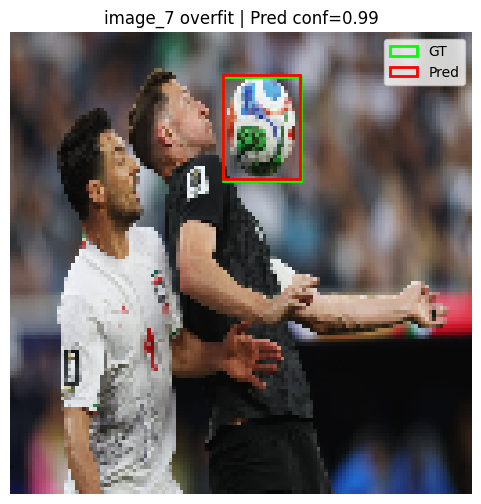

In [36]:
# Visualize on original image_7 (change index in img7_val_idx to preview others)
img = x_img7[img7_val_idx[6]]   # image_7.png
gt = y_img7[img7_val_idx[6]]

raw = model_img7(img)
pred = decode_detection(raw).data
print("ground truth:", gt)
print("prediction:  ", pred)

h_img, w_img = img.shape[:2]

def box_from_label(label):
    cx, cy, w, h, conf = label
    x1 = (cx - w / 2) * w_img
    y1 = (cy - h / 2) * h_img
    return x1, y1, w * w_img, h * h_img, conf

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(img)

if gt[4] > 0.5:
    x1, y1, bw, bh, _ = box_from_label(gt)
    ax.add_patch(plt.Rectangle((x1, y1), bw, bh, fill=False, color="lime", linewidth=2, label="GT"))

CONF_THRESH = 0.5
px1, py1, pbw, pbh, pconf = box_from_label(pred)
if pconf > CONF_THRESH:
    ax.add_patch(plt.Rectangle((px1, py1), pbw, pbh, fill=False, color="red", linewidth=2, label="Pred"))
    title = f"image_7 overfit | Pred conf={pconf:.2f}"
else:
    title = f"image_7 overfit | Pred conf={pconf:.2f} < {CONF_THRESH}"

ax.set_title(title)
ax.axis("off")
ax.legend(loc="upper right")
plt.show()

ground truth: [0.614168 0.509128 0.081155 0.11359  1.      ]
prediction:   [0.44125652 0.29860124 0.09883054 0.05761771 0.99994385]


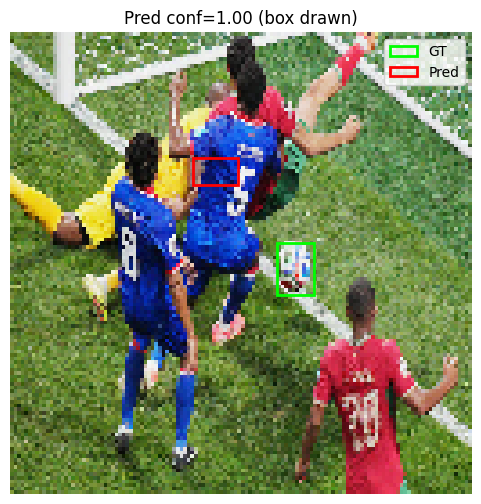

In [54]:
# Visual test on 1 test image
idx = 2  # change this to try other test images
img = x_test[idx]
gt = y_test[idx]

raw = model_img7(img)
pred = decode_detection(raw).data  # [cx, cy, w, h, conf]
print("ground truth:", gt)
print("prediction:  ", pred)

h_img, w_img = img.shape[:2]

def box_from_label(label):
    cx, cy, w, h, conf = label
    x1 = (cx - w / 2) * w_img
    y1 = (cy - h / 2) * h_img
    return x1, y1, w * w_img, h * h_img, conf

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(img)

# Ground truth (lime) — only if ball exists
if gt[4] > 0.5:
    x1, y1, bw, bh, _ = box_from_label(gt)
    ax.add_patch(plt.Rectangle((x1, y1), bw, bh, fill=False, color="lime", linewidth=2, label="GT"))

# Prediction (red) — only draw box if model is confident
CONF_THRESH = 0.5
px1, py1, pbw, pbh, pconf = box_from_label(pred)
if pconf > CONF_THRESH:
    ax.add_patch(plt.Rectangle((px1, py1), pbw, pbh, fill=False, color="red", linewidth=2, label="Pred"))
    title = f"Pred conf={pconf:.2f} (box drawn)"
else:
    title = f"Pred conf={pconf:.2f} < {CONF_THRESH} -> no ball"

ax.set_title(title)
ax.axis("off")
ax.legend(loc="upper right")
plt.show()